# Part 1: Understanding the site biomass data

## Getting set up 

First we will load packages and data 

About the datasets 

`biomass` data frame includes the following columns: 
- `Site`: ID of site that is under consideration for bison reintroduction 
- `Quadrant`: a 0.25 square meter area over which data is sampled 
- `Biomass`: amount of annual plant biomass, in grams per 0.25$m^2$

`sites` data frame includes the following columns: 
- `Site`: ID of site that is under consideration for bison reintroduction
- `Hectares`: estimation of the size of each site, in hectares 




In [1]:
# R package 
library(tidyverse)

# datasets
biomass <- read.csv("biomass.csv", header=T, sep=',')
sites <- read.csv("bison_sites.csv", header=T, sep=',')

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


💻 Use one of the following functions to preview both data sets: `View()`, `head()`, or  `str()`

In [ ]:
# add your code here 

In [ ]:
Text about groupingl, visualizing and quadrats 

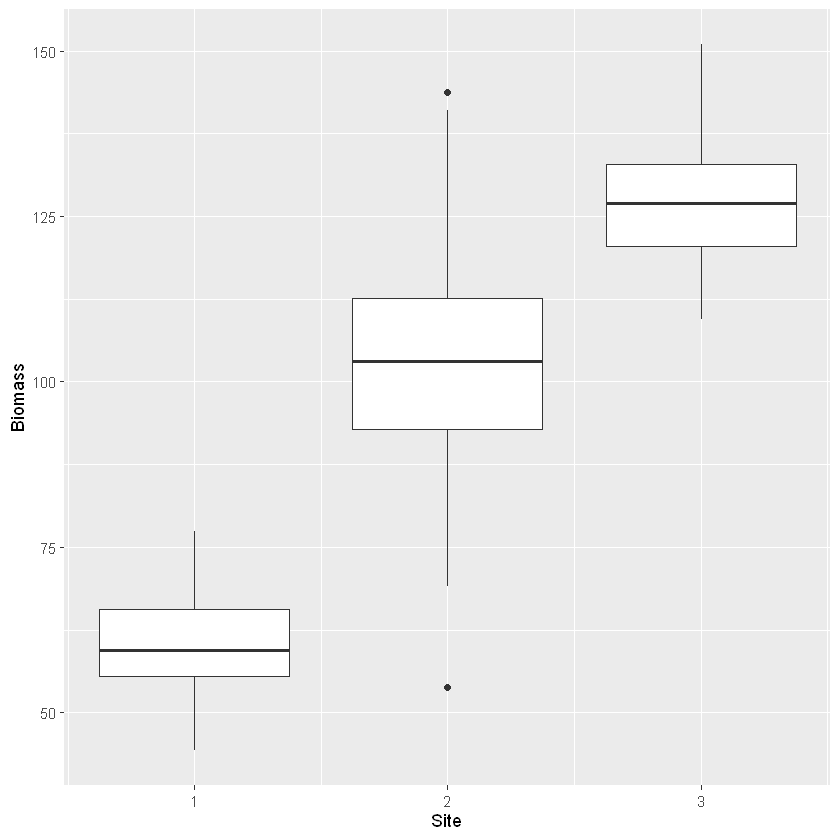

In [2]:
ggplot(biomass, aes(x=Site, y=Biomass, group=Site)) + geom_boxplot()

## Grouping data 

With the data for all of the sites in the same columns, if we took the summary statistics for a column, it would take the summary statistics for all of the sites together, rather than the summary statistics for each site. In order to run code for each site, we can use the `group_by()` function, which is part of the tidyverse. The `group_by()` function tells R to group rows of data by their shared values in a given column. A sample of this code can be seen below:

In [3]:
# group by Site 
biomass_grouped <- dplyr::group_by(biomass, Site)

# compare the output 
summarise(biomass, mean(Biomass))

# once grouped, you can apply summary functions that will maintain groupings 
summarise(biomass_grouped, mean(Biomass))

# this gives us the average plant biomass within a quadrant for each site 


mean(Biomass)
<dbl>
96.88813


Site,mean(Biomass)
<int>,<dbl>
1,60.27523
2,102.92817
3,127.46100


Now, let's look again at the data that we have: we want to figure out which sites have enough food (plant biomass) to support a herd of 200 reintroduced bison. To figure this out, the first step is to calculate the total amount of plant biomass at each site. However, as the "sites" dataset shows us, these sites are far too large to manually count up the plant biomass for the entire site. Fortunately, this is not necessary. Instead, tribal researchers collected annual plant biomass from fifty 0.25 square meter quadrats (small squares within which data is sampled) at each site, which can be used to estimate the total biomass at each site. 

While this collection method is actually feasible, this dataset doesn't quite yet give the information the tribal agriculture managers are looking for, which is the total biomass at each site. 

**A Note about tibbles**

We can see that this code chunk also just visualized the first section of our data as a table. These tables we produce are called "tibbles" in tidyverse. They are another, simpler way to view the data, and are basically the same as a data frame. If you want more information, [read more here](https://tibble.tidyverse.org/)

**A Note About dplyr**

The `dplyr` package, which is part of the tidyverse, provides numerous unique tools to easily create, edit, and manipulate data, which is often necessary when your raw data is not perfectly set up to answer the questions you are asking. Mastering these tools will give you data management skills relevant and desirable in both academic and professional settings. In this module, we will only discuss a few of the potential data management functions available, but you are encouraged to explore all of the tools and make decisions for the appropriate ones to use as you see fit! A "cheat sheet" explaining all of these functions can be found here: 
[dplyr cheat sheet](https://www.rstudio.com/wp-content/uploads/2015/02/data-wrangling-cheatsheet.pdf)

## Combine group_by and summarize 

What we have right now is the annual biomass in fifty 0.25 square meter quadrats at each site. How can we turn these fifty values into an estimate of the total biomass at each site?

We repeat the steps above, but combine them into one step using the pipe function (`%>%`). (note: Even though this code chunk produced a 3 x 2 tibble showing us average biomass at each site, this did not change the "biomass" dataset, and we can see that this tibble is not in our Global Environment, and does not actually have a name. This is because we did not give this tibble a name and assign it to a new dataset (using the <-))

In [4]:
biomass %>% 
  group_by(Site) %>% 
  summarize(avg_biomass=mean(Biomass))

Site,avg_biomass
<int>,<dbl>
1,60.27523
2,102.92817
3,127.46100


🧠✍️ Class Questions: 

* What site has the highest average plant biomass in its quadrats? What might this tell us about the viability of these sites for bison reintroduction?
* What's the problem with having data in two different units? What should we change the units to?

We take the average quadrat biomass at each site because due to the large size of the sites, it would be extremely time consuming and expensive to get an actual total biomass of each site. This average gives us an idea of the average biomass in each of the 50 quadrats where data was taken. This data is currently in g/m^2, but the site area data has been given in different units-- hectares. Bison also consume a lot of plants, with a single bison needing about 21,900 kg (1 kg = 1000g) of biomass a year to live a healthy life. So, we have data in different units from one another. Fortunately, we can easily do math in R to create new variables with updated units. 

## Lesson Recap 